In [1]:
import gymnasium as gym
import ale_py
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback

gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Environment inspection 

In [2]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("=== SPACES ===")
print("Obs space: ", env.observation_space)
print("Act space: ", env.action_space)
print("Actions:   ", env.unwrapped.get_action_meanings())

print("\n=== INFO DICT KEYS ===")
print(info)

print("\n=== ALE PROPERTIES ===")
ale = env.unwrapped.ale
print("Lives:          ", ale.lives())
print("Frame number:   ", ale.getFrameNumber())
print("Episode frames: ", ale.getEpisodeFrameNumber())
print("RAM size:       ", len(ale.getRAM()))
print("Legal actions:  ", ale.getLegalActionSet())
print("Min actions:    ", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space:  Box(0, 255, (210, 160, 3), uint8)
Act space:  Discrete(9)
Actions:    ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives:           3
Frame number:    0
Episode frames:  0
RAM size:        128
Legal actions:   [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions:     [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


## Reward Shaping Wrapper

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARD = {200, 400, 800, 1600}
    FRUIT_REWARD = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150

    def __init__(self, env,
                 ghost_chain_bonus=12.0,
                 ghost_hunt_bonus=0.0,
                 missed_ghost_penalty=0.0,
                 timing_bonus=0.0,
                 pellet_streak_bonus=0.03,
                 fruit_multiplier=1.05, 
                 death_penalty=0.0,):
        super().__init__(env)
        self.ghost_chain_bonus     = ghost_chain_bonus
        self.ghost_hunt_bonus      = ghost_hunt_bonus
        self.missed_ghost_penalty  = missed_ghost_penalty
        self.timing_bonus    = timing_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty    = death_penalty
       
        # State tracking for reward shaping
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward 
 
        # Initialise lives tracker 
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power pellet tracking
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                if self.ghosts_eaten == 0:
                    shaped_reward += self.missed_ghost_penalty * 2
                elif self.ghosts_eaten == 1:
                    shaped_reward += self.missed_ghost_penalty
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0

        # Ghost eaten
        if reward in self.GHOST_REWARD:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
            if self._power_pellet_active:
                    shaped_reward += self.ghost_hunt_bonus

        raw_reward = int(reward)
        # Pellet streak
        if raw_reward == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
        elif raw_reward == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0

            shaped_reward += self.pellet_streak_bonus * self._pellet_streak

            # Start pellet timer
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
        else:
            self._steps_since_pellet += 1

            # Break if too much without eating a pellet
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0

        # Fruit multiplier
        if raw_reward in self.FRUIT_REWARD:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw_reward

        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
 
        return obs, shaped_reward, terminated, truncated, info

## Experimental Conditions

In [5]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "#4C9BE8",
        "description": "Default ALE rewards only"
    },

    "Death Penalty": {
        "wrapper": "simple",
        "survival_bonus": 0.0, 
        "death_penalty": -5.0,
        "power_pellet_bonus": 0.0,
        "color": "#57C97A",
        "description": "-5 on each life lost"
    },

    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "ghost_hunt_bonus": 0.0,
        "missed_ghost_penalty": 0.0,
        "timing_bonus": 0.0,
        "pellet_streak_bonus": 0.3,
        "fruit_multiplier": 1.5, 
        "death_penalty": -5.0,    
        "color": "#C97AE8",
        "description": "Expert: chain + streak + fruit + small penalty"
    },

   "Expert No Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus":    12.0, 
        "ghost_hunt_bonus":      0.0,
        "missed_ghost_penalty":  0.0,
        "timing_bonus":          0.0,
        "pellet_streak_bonus":   0.3,
        "fruit_multiplier":      1.5,
        "death_penalty":         0.0, 
        "color": "#E8C94C",
        "description": "Expert signals only, no death penalty"
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:20s} — {cfg['description']}")

Conditions defined:
  Baseline             — Default ALE rewards only
  Death Penalty        — -5 on each life lost
  Expert Shaping       — Expert: chain + streak + fruit + small penalty
  Expert No Death Penalty — Expert signals only, no death penalty


## Progress Callback (tracks metrics per episode)

In [6]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose=0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0
        self._current_length = 0
 
    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1
 
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0
            self._current_length = 0
            if len(self.episode_rewards) % 50 == 0:
                recent_r = np.mean(self.episode_rewards[-20:])
                recent_l = np.mean(self.episode_lengths[-20:])
                print(f"  [{self.condition_name}] "
                      f"Ep {len(self.episode_rewards):>4} | "
                      f"Steps {self.num_timesteps:>7,} | "
                      f"Avg reward: {recent_r:>7.1f} | "
                      f"Avg length: {recent_l:>5.0f}")
        return True
 

## Training Function

In [7]:
def make_env(condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5")
        env.reset(seed=seed)
        if condition_cfg["wrapper"] == None:
            pass
        elif condition_cfg["wrapper"] == "simple":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus=0.0,
                ghost_hunt_bonus=0.0,
                missed_ghost_penalty=0.0,
                timing_bonus=0.0,
                pellet_streak_bonus=0.0,
                fruit_multiplier=1.0,
                death_penalty=condition_cfg.get("death_penalty", 0.0),

            )
        elif condition_cfg["wrapper"] == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus=condition_cfg.get("ghost_chain_bonus", 0.0),
                ghost_hunt_bonus=condition_cfg.get("ghost_hunt_bonus", 0.0),
                missed_ghost_penalty=condition_cfg.get("missed_ghost_penalty", 0.0),
                timing_bonus=condition_cfg.get("timing_bonus", 0.0),
                pellet_streak_bonus=condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier=condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty=condition_cfg.get("death_penalty", 0.0),
            )
        
        env = AtariWrapper(env, clip_reward=False)
        return env
    return _init
 
def train_condition(condition_name, condition_cfg, total_timesteps=1000000, seed=42):
    print(f"\n{'='*60}")
    print(f"Training: {condition_name}")
    print(f"Config:   {condition_cfg['description']}")
    print(f"Steps:    {total_timesteps:,}")

    vec_env = DummyVecEnv([make_env(condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)

    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps=128,
        batch_size=256,
        n_epochs=4,
        gamma=0.99,
        learning_rate=2.5e-4,
        clip_range=0.1,
        verbose=0,
        seed=seed,
    )

    callback = ExperimentCallback(condition_name)

    model.learn(total_timesteps=total_timesteps, callback=callback)
    steps_str = f"{total_timesteps // 1_000_000}M"
    save_path = f"ppo_pacman_{condition_name.replace(' ', '_').lower()}_{steps_str}"
    model.save(save_path)
    print(f"  Saved to {save_path}.zip")

    # Save training log for analysis cells
    log_path = f"training_log_{condition_name.replace(' ', '_').lower()}_{steps_str}.json"
    with open(log_path, "w") as f:
        json.dump({
            "condition": condition_name,
            "total_steps": total_timesteps,
            "episode_rewards": [float(x) for x in callback.episode_rewards],
            "episode_lengths": [int(x) for x in callback.episode_lengths],
        }, f,)
    print(f"  Training log saved to {log_path}")

    vec_env.close()
    return model, callback

In [10]:
TOTAL_STEPS = 1_000_000

In [ ]:
results = {} 
 
for name, cfg in CONDITIONS.items():
    try:
        model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
        results[name] = {
            "callback": callback,
            "model": model,
            "episode_rewards": callback.episode_rewards,
            "episode_lengths": callback.episode_lengths,
            "total_steps": TOTAL_STEPS,
        }
        print(f"  Completed training for {name}.")
    except Exception as e:
        print(f"  Error during training for {name}: {e}")
        results[name] = None
 
print(f"\nAll conditions trained! {TOTAL_STEPS:,} steps each.")


Training: Baseline
Config:   Default ALE rewards only
Steps:    1,000,000


g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps   2,442 | Avg reward:   199.0 | Avg length:    57
  [Baseline] Ep  100 | Steps   5,198 | Avg reward:   136.0 | Avg length:    54
  [Baseline] Ep  150 | Steps   7,854 | Avg reward:   131.5 | Avg length:    50
  [Baseline] Ep  200 | Steps  10,574 | Avg reward:   166.5 | Avg length:    49
  [Baseline] Ep  250 | Steps  13,221 | Avg reward:   186.0 | Avg length:    55
  [Baseline] Ep  300 | Steps  15,885 | Avg reward:   156.0 | Avg length:    55
  [Baseline] Ep  350 | Steps  18,519 | Avg reward:   196.5 | Avg length:    58
  [Baseline] Ep  400 | Steps  21,117 | Avg reward:   152.0 | Avg length:    51
  [Baseline] Ep  450 | Steps  23,688 | Avg reward:   135.0 | Avg length:    50
  [Baseline] Ep  500 | Steps  25,940 | Avg reward:   109.0 | Avg length:    47
  [Baseline] Ep  550 | Steps  28,506 | Avg reward:   256.0 | Avg length:    57
  [Baseline] Ep  600 | Steps  31,236 | Avg reward:   408.0 | Avg length:    56
  [Baseline] Ep  650 | Steps  33,602 | Avg reward:  

g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Death Penalty] Ep   50 | Steps   2,233 | Avg reward:   184.0 | Avg length:    51
  [Death Penalty] Ep  100 | Steps   4,112 | Avg reward:    82.5 | Avg length:    37
  [Death Penalty] Ep  150 | Steps   6,790 | Avg reward:   139.5 | Avg length:    48
  [Death Penalty] Ep  200 | Steps   9,599 | Avg reward:   236.0 | Avg length:    53
  [Death Penalty] Ep  250 | Steps  12,174 | Avg reward:   164.5 | Avg length:    56
  [Death Penalty] Ep  300 | Steps  14,546 | Avg reward:   142.0 | Avg length:    40
  [Death Penalty] Ep  350 | Steps  16,636 | Avg reward:    94.0 | Avg length:    32
  [Death Penalty] Ep  400 | Steps  18,620 | Avg reward:   160.0 | Avg length:    33
  [Death Penalty] Ep  450 | Steps  20,817 | Avg reward:   194.5 | Avg length:    49
  [Death Penalty] Ep  500 | Steps  23,127 | Avg reward:   161.5 | Avg length:    41
  [Death Penalty] Ep  550 | Steps  24,880 | Avg reward:   107.5 | Avg length:    34
  [Death Penalty] Ep  600 | Steps  26,820 | Avg reward:   150.5 | Avg length

## Evaluation Function

In [11]:
def evaluate_agent(model, n_episodes=100, seed=99):
    def make_eval_env():
        env = gym.make("ALE/MsPacman-v5")
        env.reset(seed=seed)
        env = AtariWrapper(env, clip_reward=False) 
        return env

    eval_env = DummyVecEnv([make_eval_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)

    # Per-episode metrics
    scores = []
    lengths = []
    ghost_chains = []
    ghosts_eaten = []     
    score_per_step = []   

    for ep in range(n_episodes):
        obs           = eval_env.reset()
        total_score   = 0
        length        = 0
        done          = False
        current_chain = 0
        max_chain     = 0
        ep_ghosts     = 0        
        prev_lives    = 3

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = eval_env.step(action)
            r = reward[0]
            total_score += r
            length      += 1

            # Track ghost chaining
            if r in [200, 400, 800, 1600]:
                current_chain  += 1
                max_chain       = max(max_chain, current_chain)
                ep_ghosts      += 1                
            elif r == 50:
                current_chain   = 0                               

            # Track deaths
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                current_chain = 0                  
            prev_lives = current_lives

        scores.append(total_score)
        lengths.append(length)
        ghost_chains.append(max_chain)
        ghosts_eaten.append(ep_ghosts)                                    
        score_per_step.append(total_score / length if length > 0 else 0)  

    eval_env.close()

    return {
        "scores": np.array(scores),
        "lengths": np.array(lengths),
        "ghost_chains": np.array(ghost_chains),
        "ghosts_eaten": np.array(ghosts_eaten),     
        "score_per_step": np.array(score_per_step),       
    }

## Evaluate All Conditions

In [12]:
eval_results = {}
steps_str    = f"{TOTAL_STEPS // 1_000_000}M"

for name, data in results.items():
    if data is None:
        print(f"Skipping {name} — training failed")
        continue

    print(f"Evaluating {name}...")
    er = evaluate_agent(data["model"], n_episodes=100, seed=99)
    eval_results[name] = er

    # Save to disk after each condition
    save_name = f"eval_{name.replace(' ', '_').lower()}_{steps_str}.json"
    with open(save_name, "w") as f:
        json.dump({
            "condition": name,
            "steps": TOTAL_STEPS,
            "scores": er["scores"].tolist(),
            "lengths": er["lengths"].tolist(),
            "ghost_chains": er["ghost_chains"].tolist(),
            "ghosts_eaten": er["ghosts_eaten"].tolist(), 
            "score_per_step": er["score_per_step"].tolist(),
        }, f)
    print(f"  Saved to {save_name}")

# Display summary table 
display(pd.DataFrame({
    cond: {
        "Avg Score": round(np.mean(er["scores"]), 1),
        "Std": round(np.std(er["scores"]), 1),
        "Survival": round(np.mean(er["lengths"]), 1),
        "Ghost Chain": round(np.mean(er["ghost_chains"]), 2),
        "Ghosts/ep": round(np.mean(er["ghosts_eaten"]), 1),
        "Score/step": round(np.mean(er["score_per_step"]), 3),
    }
    for cond, er in eval_results.items()
}).T)

NameError: name 'results' is not defined

## Learning Efficiency Analysis 

Learning Efficiency Analysis-1M steps
Method: per-condition threshold (50% of each condition's own best reward)


""


C:\Users\traan\AppData\Local\Temp\ipykernel_21992\178770833.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=9)


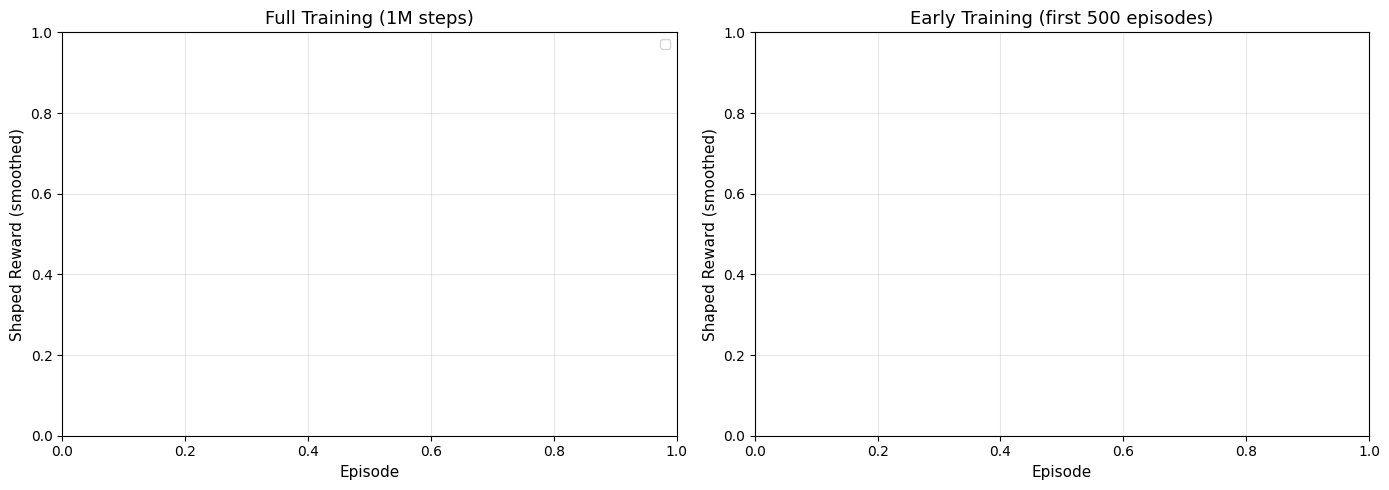

Saved plot_learning_curves_1M.png


In [23]:
def smooth(arr, window=50):
    arr = np.array(arr, dtype=float)
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")

def steps_to_threshold(episode_rewards, episode_lengths, threshold, window=50):
    rewards = np.array(episode_rewards, dtype=float)
    lengths = np.array(episode_lengths, dtype=float)
    smoothed = smooth(rewards, window)
    above = np.where(smoothed >= threshold)[0]
    if len(above) == 0:
        return None, None
    episode_idx = int(above[0]) + window
    steps_count = int(np.sum(lengths[:episode_idx]))
    return episode_idx, steps_count

print(f"Learning Efficiency Analysis-{TOTAL_STEPS // 1_000_000}M steps")
print(f"Method: per-condition threshold (50% of each condition's own best reward)")

efficiency = {}

for name, data in results.items():
    if data is None:
        continue

    rewards = np.array(data["episode_rewards"], dtype=float)
    smoothed = smooth(rewards, window=50)
    own_best = float(np.max(smoothed))
    own_threshold = 0.5 * own_best
    final_train = float(np.mean(rewards[-100:]))
    eval_score = np.mean(eval_results[name]["scores"])

    ep, steps = steps_to_threshold(
        rewards,
        data["episode_lengths"],
        own_threshold,
    )

    efficiency[name] = {
        "threshold": own_threshold,
        "episodes_to_threshold": ep,
        "steps_to_threshold": steps,
        "final_train_avg": final_train,
        "eval_score": eval_score,
    }

display(pd.DataFrame({
    name: {
        "Threshold":  round(e["threshold"], 1),
        "Episodes":   e["episodes_to_threshold"] or "Never",
        "Steps":      f"{e['steps_to_threshold']:,}" if e["steps_to_threshold"] else "Never",
        "Train Avg":  round(e["final_train_avg"], 1),
        "Eval Score": round(e["eval_score"], 1),
    }
    for name, e in efficiency.items()
}).T)

# Plot learning curves
def plot_learning_curves(results, CONDITIONS, TOTAL_STEPS, full_window=50, early_window=20, early_episodes=500):
    fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

    for name, data in results.items():
        if data is None:
            continue

        color   = CONDITIONS[name]["color"]
        rewards = np.array(data["episode_rewards"], dtype=float)
        for ax, rew, window in [
            (axes[0], rewards,full_window),
            (axes[1], rewards[:early_episodes], early_window),
        ]:
            smoothed = smooth(rew, window)
            ax.plot(np.arange(len(rew)), rew, color=color, alpha=0.15, linewidth=0.5)
            ax.plot(np.arange(len(smoothed)), smoothed, color=color, linewidth=2)

        axes[0].plot([], [], color=color, linewidth=2, label=name)

    for ax, title in zip(axes, [
        f"Full Training ({TOTAL_STEPS // 1_000_000}M steps)",
        f"Early Training (first {early_episodes} episodes)",
    ]):
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Episode", fontsize=11)
        ax.set_ylabel("Shaped Reward (smoothed)", fontsize=11)
        ax.grid(alpha=0.3)

    axes[0].legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{TOTAL_STEPS // 1_000_000}M.png", dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved plot_learning_curves_{TOTAL_STEPS // 1_000_000}M.png")


plot_learning_curves(results, CONDITIONS, TOTAL_STEPS)

## Statistical Summary 

In [24]:
print(f"\nFULL STATISTICAL SUMMARY-{TOTAL_STEPS // 1_000_000}M steps")

display(pd.DataFrame({
    name: {
        "Mean Score": round(np.mean(er["scores"]), 1),
        "Std": round(np.std(er["scores"]), 1),
        "Max Score": int(np.max(er["scores"])),
        "Survival": round(np.mean(er["lengths"]), 1),
        "Ghost Chain": round(np.mean(er["ghost_chains"]), 2),
        "Ghosts/ep": round(np.mean(er["ghosts_eaten_total"]), 1),
        "Score/step": round(np.mean(er["score_per_step"]), 3),
    }
    for name, er in eval_results.items()
}).T)

# Baseline comparison table 
if "Baseline" in eval_results:
    b_score  = np.mean(eval_results["Baseline"]["scores"])
    b_length = np.mean(eval_results["Baseline"]["lengths"])

    print(f"\nComparison vs Baseline")
    display(pd.DataFrame({
        name: {
            "Score Diff": round(np.mean(er["scores"]) - b_score,  1),
            "Beats BL?": "YES" if np.mean(er["scores"]) > b_score  else "NO",
            "Survival Diff":round(np.mean(er["lengths"]) - b_length, 1),
            "Survival Dir": "↑" if np.mean(er["lengths"]) - b_length > 1
                            else "↓" if np.mean(er["lengths"]) - b_length < -1
                            else "=",
        }
        for name, er in eval_results.items()
    }).T)


FULL STATISTICAL SUMMARY-1M steps


""


## Score Distribution Box Plot

C:\Users\traan\AppData\Local\Temp\ipykernel_21992\481920635.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


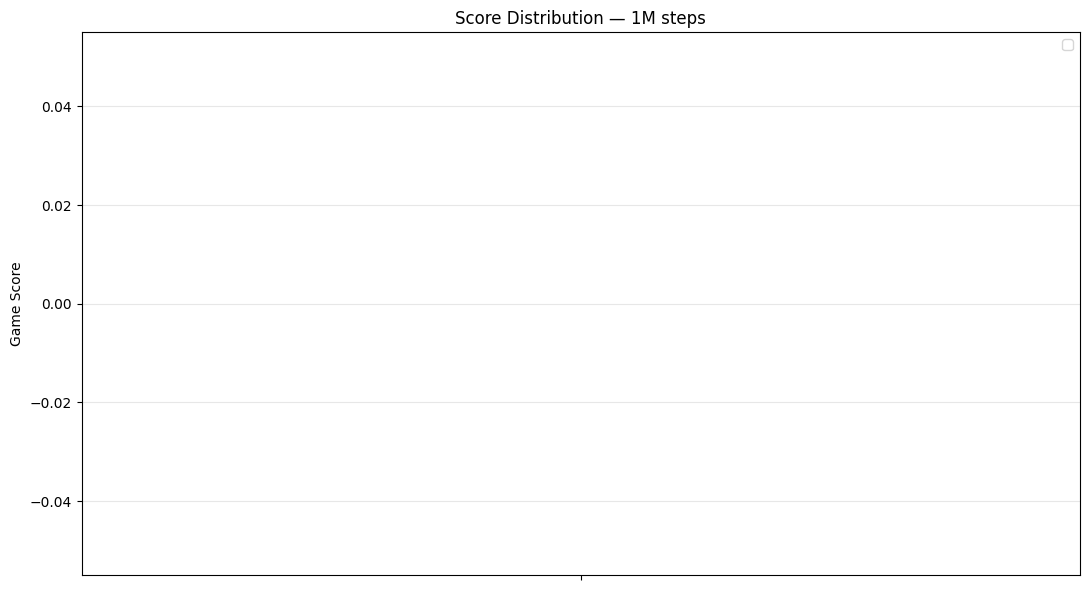

In [25]:
def plot_score_distribution(eval_results, CONDITIONS, TOTAL_STEPS):
    names = list(eval_results.keys())
    fig, ax = plt.subplots(figsize=(11, 6))
    bp = ax.boxplot(
        [eval_results[n]["scores"] for n in names],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, n in zip(bp["boxes"], names):
        patch.set_facecolor(CONDITIONS[n]["color"])
        patch.set_alpha(0.7)

    # Data points + mean markers
    np.random.seed(42)
    for i, n in enumerate(names):
        scores = eval_results[n]["scores"]
        ax.scatter(np.full(len(scores), i+1) + np.random.uniform(-0.15, 0.15, len(scores)),
                   scores, alpha=0.25, s=12, color=CONDITIONS[n]["color"], zorder=3)
        ax.plot(i+1, np.mean(scores), "D", color="white",
                markeredgecolor="black", markersize=9, zorder=6)

    # Baseline reference
    if "Baseline" in eval_results:
        bm = np.median(eval_results["Baseline"]["scores"])
        ax.axhline(bm, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline median ({bm:.0f})")

    ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel("Game Score")
    ax.set_title(f"Score Distribution — {TOTAL_STEPS // 1_000_000}M steps")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_score_distribution_{TOTAL_STEPS // 1_000_000}M.png", dpi=130, bbox_inches="tight")
    plt.show()

plot_score_distribution(eval_results, CONDITIONS, TOTAL_STEPS)

Reward Hacking Detection 

In [29]:
if results.get("Baseline") is None or eval_results.get("Baseline") is None:
    raise ValueError("Baseline results are missing — make sure the Baseline agent ran successfully before this cell.")

baseline_train = np.mean(results["Baseline"]["episode_rewards"][-100:])
baseline_eval  = np.mean(eval_results["Baseline"]["scores"])

hacking_summary = {}

for name, data in results.items():
    if data is None or name not in eval_results:
        continue

    train_r = np.mean(data["episode_rewards"][-100:])
    eval_s = np.mean(eval_results[name]["scores"])
    ratio = round(eval_s / train_r, 2) if train_r > 0 else 1.0

    train_inflated = train_r > baseline_train
    eval_degraded = eval_s < baseline_eval
    ratio_low = ratio < 0.6

    if name == "Baseline":
        verdict = "Reference"
    elif train_inflated and eval_degraded and ratio_low:
        verdict = "HACKING"
    elif train_inflated and eval_degraded:
        verdict = "LIKELY"
    elif eval_degraded:
        verdict = "Underperforms"
    else:
        verdict = "Clean"

    hacking_summary[name] = {
        "Train Reward": round(train_r, 1),
        "Eval Score":   round(eval_s, 1),
        "Ratio":        ratio,
        "vs BL":        round(eval_s - baseline_eval, 1),
        "Verdict":      verdict,
    }

print(f"\nREWARD HACKING ANALYSIS — {TOTAL_STEPS // 1_000_000}M steps")
print("Ratio = eval/train (1.0=clean, <0.6=likely hacking)")
display(pd.DataFrame(hacking_summary).T)


REWARD HACKING ANALYSIS — 1M steps
Ratio = eval/train (1.0=clean, <0.6=likely hacking)


g:\PacManRLTraining\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
g:\PacManRLTraining\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Train Reward,Eval Score,Ratio,vs BL,Verdict
Baseline,NaN,176.699997,1.0,0.0,Reference
Death Penalty,NaN,105.300003,1.0,-71.400002,Underperforms
Expert Shaping,NaN,71.400002,1.0,-105.300003,Underperforms
Expert No Death Penalty,NaN,156.800003,1.0,-19.9,Underperforms


Research Question Answer Matrix

In [31]:
baseline_score  = np.mean(eval_results["Baseline"]["scores"])
baseline_length = np.mean(eval_results["Baseline"]["lengths"])
baseline_chain  = np.mean(eval_results["Baseline"]["ghost_chains"])
baseline_sp     = np.mean(eval_results["Baseline"]["score_per_step"])
baseline_ghosts = np.mean(eval_results["Baseline"]["ghosts_eaten"])
baseline_train  = np.mean(results["Baseline"]["episode_rewards"][-100:])

def arrow(val, threshold=0.5):
    if val >  threshold: return "↑"
    if val < -threshold: return "↓"
    return "="

# RQ1 
print(f"\nRQ1: Does strategy-informed shaping outperform naive shaping?-{TOTAL_STEPS // 1_000_000}M steps")
display(pd.DataFrame({
    name: {
        "Eval Score": round(np.mean(er["scores"]), 1),
        "vs Baseline": round(np.mean(er["scores"]) - baseline_score, 1),
        "Verdict": "Reference" if name == "Baseline"
                   else "BEATS" if np.mean(er["scores"]) > baseline_score
                   else "Similar" if np.mean(er["scores"]) > baseline_score - 20
                   else "BELOW",
    }
    for name, er in eval_results.items()
}).T)

# RQ2 
print(f"\nRQ2: Did shaping alter behaviour beyond score?")
display(pd.DataFrame({
    name: {
        "Survival":    f"{arrow(d := np.mean(er['lengths'])  - baseline_length)}{d:+.1f}",
        "Chain":       f"{arrow(d := np.mean(er['ghost_chains']) - baseline_chain, 0.05)}{d:+.2f}",
        "Ghosts":      f"{arrow(d := np.mean(er['ghosts_eaten']) - baseline_ghosts, 0.05)}{d:+.2f}",
        "Score/step":  f"{arrow(d := np.mean(er['score_per_step']) - baseline_sp, 0.001)}{d:+.3f}",
    }
    for name, er in eval_results.items()
}).T)

# RQ3 
print(f"\nRQ3: Is there evidence of reward hacking?")
display(pd.DataFrame({
    name: {
        "Train":   round(t := np.mean(data["episode_rewards"][-100:]), 1),
        "Eval":    round(e := np.mean(eval_results[name]["scores"]), 1),
        "Ratio":   round(e / t if t > 0 else 1.0, 2),
        "vs BL":   round(t - baseline_train, 1),
        "Verdict": "Reference" if name == "Baseline"
                   else "HACKING ⚠" if t > baseline_train and e < baseline_score and e/t < 0.6
                   else "LIKELY ⚠"  if t > baseline_train and e < baseline_score
                   else "Underperforms" if e < baseline_score
                   else "Clean",
    }
    for name, data in results.items()
    if data is not None and name in eval_results
}).T)

print(f"\nRatio = eval/train (1.0=clean, <0.6=hacking)")
print(f"↑↓= = above/below/similar to baseline")


RQ1: Does strategy-informed shaping outperform naive shaping?-1M steps


g:\PacManRLTraining\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
g:\PacManRLTraining\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Eval Score,vs Baseline,Verdict
Baseline,176.699997,0.0,Reference
Death Penalty,105.300003,-71.400002,BELOW
Expert Shaping,71.400002,-105.300003,BELOW
Expert No Death Penalty,156.800003,-19.9,Similar



RQ2: Did shaping alter behaviour beyond score?


,Survival,Chain,Ghosts,Score/step
Baseline,=+0.0,=+0.00,=+0.00,=+0.000
Death Penalty,↓-2.2,=-0.03,=-0.03,↓-1.197
Expert Shaping,↓-17.0,=-0.03,=-0.03,↓-1.851
Expert No Death Penalty,↓-6.4,=-0.03,=-0.03,↑+0.024



RQ3: Is there evidence of reward hacking?


g:\PacManRLTraining\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
g:\PacManRLTraining\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Train,Eval,Ratio,vs BL,Verdict
Baseline,NaN,176.699997,1.0,NaN,Reference
Death Penalty,NaN,105.300003,1.0,NaN,Underperforms
Expert Shaping,NaN,71.400002,1.0,NaN,Underperforms
Expert No Death Penalty,NaN,156.800003,1.0,NaN,Underperforms



Ratio = eval/train (1.0=clean, <0.6=hacking)
↑↓= = above/below/similar to baseline


## Evaluation of the saved models

In [28]:
TOTAL_STEPS  = 1_000_000 

name_to_file = {
    "Baseline": "ppo_pacman_baseline",
    "Death Penalty": "ppo_pacman_death_penalty",
    "Expert Shaping": "ppo_pacman_expert_shaping",
    "Expert No Death Penalty": "ppo_pacman_expert_no_death_penalty",
}

eval_results = {}
results      = {}

for name, file_base in name_to_file.items():
    zip_path = f"{file_base}_{TOTAL_STEPS // 1_000_000}M"
    training_path = f"training_{name.replace(' ', '_').lower()}_{TOTAL_STEPS // 1_000_000}M.json"
    eval_path = f"eval_{name.replace(' ', '_').lower()}_{TOTAL_STEPS // 1_000_000}M.json"

    # Load model
    try:
        model = PPO.load(zip_path)
        print(f"Loaded {zip_path}.zip")
    except FileNotFoundError:
        print(f"  {zip_path}.zip not found — skipping {name}")
        results[name] = None
        continue

    # Evaluate
    er = evaluate_agent(model, n_episodes=100, seed=99)
    eval_results[name] = er

    # Load training log
    try:
        with open(training_path) as f:
            td = json.load(f)
        results[name] = {
            "episode_rewards": td["episode_rewards"],
            "episode_lengths": td["episode_lengths"],
            "total_steps": TOTAL_STEPS,
            "model": model,
        }
        print(f"  Training log loaded")

    except FileNotFoundError:
        print(f"  No training log found")
        results[name] = {
            "episode_rewards": [],
            "episode_lengths": [],
            "total_steps": TOTAL_STEPS,
            "model": model,
        }
    print()

# Summary table
display(pd.DataFrame({
    name: {
        "Avg Score": round(np.mean(er["scores"]), 1),
        "Std": round(np.std(er["scores"]), 1),
        "Survival": round(np.mean(er["lengths"]), 1),
        "Ghost Chain": round(np.mean(er["ghost_chains"]), 2),
        "Ghosts/ep": round(np.mean(er["ghosts_eaten"]), 1),
        "Score/step": round(np.mean(er["score_per_step"]), 3),
    }
    for name, er in eval_results.items()
}).T)

print(f"\n{len(eval_results)} conditions loaded — {TOTAL_STEPS} run")

Loaded ppo_pacman_baseline_1M.zip
  No training log found

Loaded ppo_pacman_death_penalty_1M.zip
  No training log found

Loaded ppo_pacman_expert_shaping_1M.zip
  No training log found

Loaded ppo_pacman_expert_no_death_penalty_1M.zip
  No training log found



,Avg Score,Std,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,176.699997,123.000000,45.7,0.03,0.0,3.713
Death Penalty,105.300003,106.599998,43.5,0.00,0.0,2.516
Expert Shaping,71.400002,99.500000,28.7,0.00,0.0,1.861
Expert No Death Penalty,156.800003,98.800003,39.4,0.00,0.0,3.737



4 conditions loaded — 1000000 run
